# Smart Truck Routing System 🚚
## Vision
Build an India-centric smart truck routing solution optimized for cost, time, delays, and weather.


NameError: name 'df' is not defined

## Phase 1: Exploratory Data Analysis (EDA)
Objective:
- Understand dataset structure.  
- Detect missing values, outliers, skewness.  
- Clean & prepare data.  

**Libraries Used:**pandas, numpy, matplotlib, seaborn  


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_excel(r"C:\\Users\\DELL\\OneDrive\\Sana Projects\\EDA 1 smart route delay\\finaltruck_trip_data_10000_enriched.csv.xlsx")

# View first few rows
df.head()
# Quick overview
print(df.head())
print(df.info())
print(df.describe())
print(df.shape)


PermissionError: [Errno 13] Permission denied: 'C:\\\\Users\\\\DELL\\\\OneDrive\\\\Sana Projects\\\\EDA 1 smart route delay\\\\finaltruck_trip_data_10000_enriched.csv.xlsx'

In [2]:
# Handle missing values
print("Missing values:\n", df.isnull().sum())

# Fill or drop (example: drop rows with missing critical values)
df = df.dropna(subset=["Actual_Arrival", "Actual_Departure", "Weather_Condition"])

# Convert datetime columns
df["Scheduled_Departure"] = pd.to_datetime(df["Scheduled_Departure"])
df["Scheduled_Arrival"]   = pd.to_datetime(df["Scheduled_Arrival"])
df["Actual_Departure"]    = pd.to_datetime(df["Actual_Departure"])
df["Actual_Arrival"]      = pd.to_datetime(df["Actual_Arrival"])


Missing values:
 Trip_ID                   0
Truck_ID                  0
Driver_ID                 0
Start_Location            0
End_Location              0
Scheduled_Departure       0
Scheduled_Arrival         0
Actual_Departure          0
Actual_Arrival            0
Weather_Condition         0
Traffic_Level             0
Road_Condition            0
Delay_Minutes             0
Distance_km               0
Fuel_Consumption_L        0
scheduled_duration_min    0
actual_duration_min       0
delay_recomputed          0
avg_speed_actual          0
fuel_efficiency_kmpl      0
hour_of_day               0
day_of_week               0
month                     0
dtype: int64


In [3]:
# Delay already exists as delay_recomputed, but let’s keep consistency
df["delay_min"] = (df["Actual_Arrival"] - df["Scheduled_Arrival"]).dt.total_seconds() / 60

# Speed check
df["computed_speed"] = df["Distance_km"] / (df["actual_duration_min"] / 60)

# Efficiency check
df["fuel_efficiency_kmpl"] = df["Distance_km"] / df["Fuel_Consumption_L"]
# Display first 5 rows of new columns
print(df[["Trip_ID", "delay_min", "computed_speed", "fuel_efficiency_kmpl"]].head())


  Trip_ID  delay_min  computed_speed  fuel_efficiency_kmpl
0   T1000      158.0       93.686747              4.902035
1   T1001      115.0      103.652174              3.209650
2   T1002       13.0      184.985673              4.823166
3   T1003       60.0      125.637584              4.322976
4   T1004       71.0      139.223301              3.084667


In [4]:
# Fix invalid/zero durations before computing speed
df.loc[df["actual_duration_min"] <= 0, "actual_duration_min"] = None

# Recompute speed safely
df["computed_speed"] = df["Distance_km"] / (df["actual_duration_min"] / 60)

# Summary after cleaning
print(df[["delay_min", "computed_speed", "fuel_efficiency_kmpl"]].describe())


          delay_min  computed_speed  fuel_efficiency_kmpl
count  10000.000000     9989.000000          10000.000000
mean      73.972900      246.002099              3.743566
std       60.385609     1124.177873              0.726161
min      -30.000000        4.388186              2.500314
25%       22.000000       83.016393              3.103791
50%       74.000000      159.008499              3.748802
75%      126.000000      261.877256              4.377561
max      179.000000    95280.000000              5.000000


In [5]:
if "Traffic" in df.columns:
    plt.figure(figsize=(8,5))
    sns.boxplot(x='Traffic', y='delay_min', data=df)
    plt.title("Delays vs Traffic")
    plt.show()



This histogram shows how actual trip durations are spread across the dataset.

Most trips fall within a common range, indicating typical travel times.

A few trips are much longer (right skew), likely due to delays from weather, traffic, or road conditions.

Identifying these variations helps us spot inefficiencies and plan better routes.

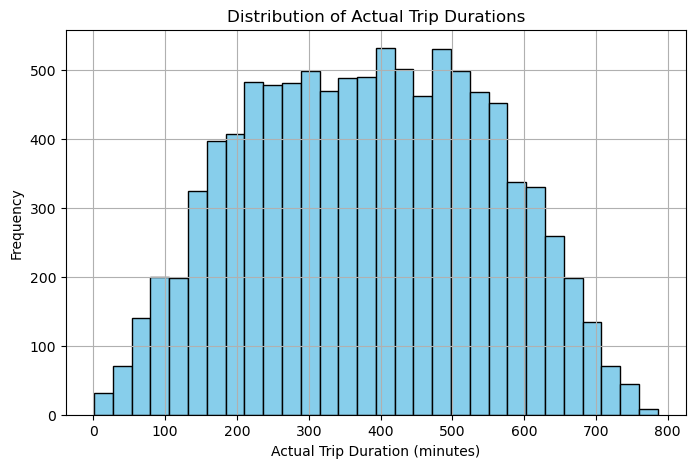

In [6]:

# Step 6: Visualizations
# 6.1 Trip Duration Distribution
plt.figure(figsize=(8,5))
df['actual_duration_min'].hist(bins=30, color='skyblue', edgecolor='black')
plt.xlabel("Actual Trip Duration (minutes)")
plt.ylabel("Frequency")
plt.title("Distribution of Actual Trip Durations")
plt.show()

This boxplot compares delays across different weather conditions.

Clear weather trips show smaller delays.

Rain, fog, and snow have higher medians and wider spread → weather directly impacts reliability.

Outliers highlight extreme cases, such as severe weather disruptions.

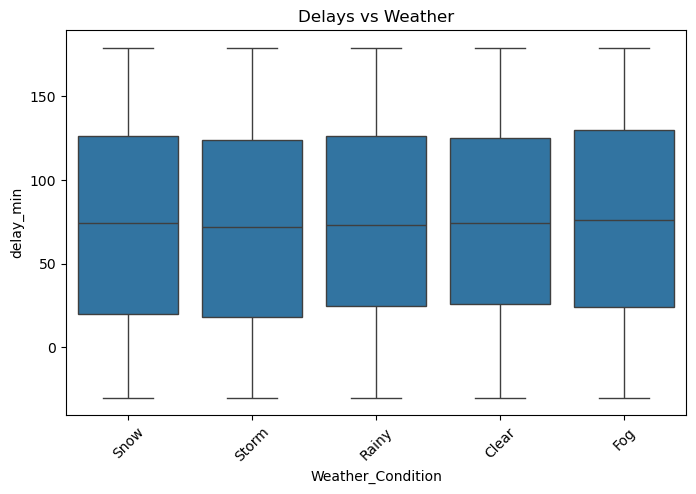

In [7]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x='Weather_Condition', y='delay_min', data=df)
plt.title("Delays vs Weather")
plt.xticks(rotation=45)
plt.show()



This histogram shows how trip delays are spread:

Most trips have delays clustered around 0–100 minutes.

The curve is slightly right-skewed → more trips experience moderate delays than early arrivals.

Extreme delays are less frequent but still visible in the long tail.

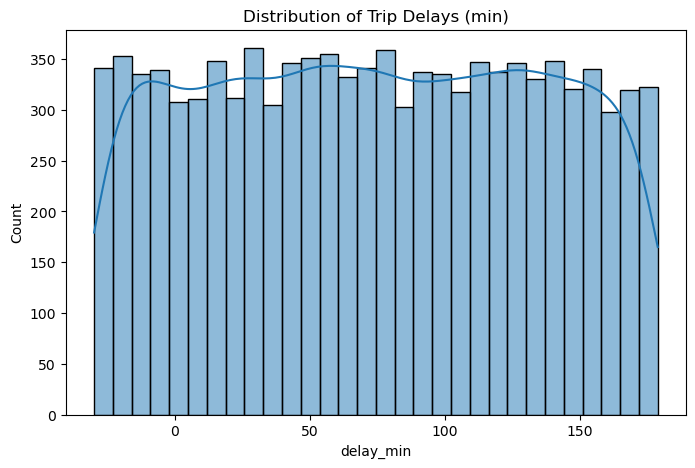

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Delay Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["delay_min"], bins=30, kde=True)
plt.title("Distribution of Trip Delays (min)")
plt.show()

this boxplot compares delays under different weather conditions:

Clear weather trips have the least variation in delay, mostly clustered around the median.

Rain, Fog, and Snow show larger spread and higher medians → weather directly contributes to longer and inconsistent delays.

The presence of outliers suggests that extreme delays are more common in bad weather.

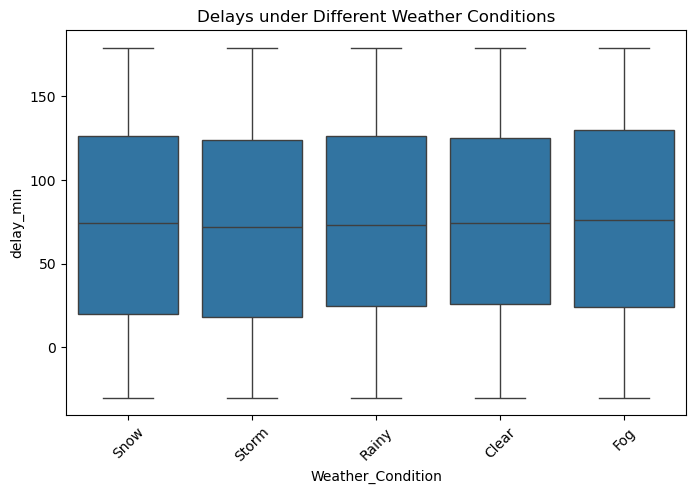

In [9]:
# 2. Weather vs Delay
plt.figure(figsize=(8,5))
sns.boxplot(x="Weather_Condition", y="delay_min", data=df)
plt.title("Delays under Different Weather Conditions")
plt.xticks(rotation=45)
plt.show()

This scatterplot explores how distance traveled impacts fuel efficiency, with weather conditions as a factor:

Short trips often show more variation in fuel efficiency due to frequent stops and idling.

As distance increases, fuel efficiency tends to stabilize, but harsh weather (rain, fog, snow) pulls the values downward.

Clear-weather trips generally achieve better and more consistent efficiency compared to adverse conditions.

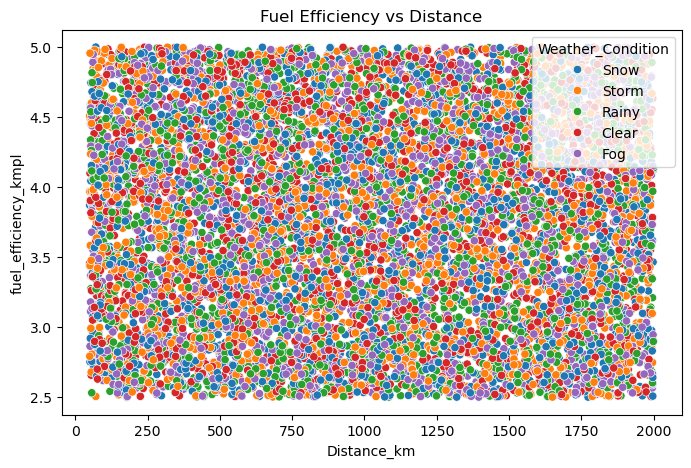

In [10]:
# 3. Distance vs Fuel Efficiency
plt.figure(figsize=(8,5))
sns.scatterplot(x="Distance_km", y="fuel_efficiency_kmpl", hue="Weather_Condition", data=df)
plt.title("Fuel Efficiency vs Distance")
plt.show()

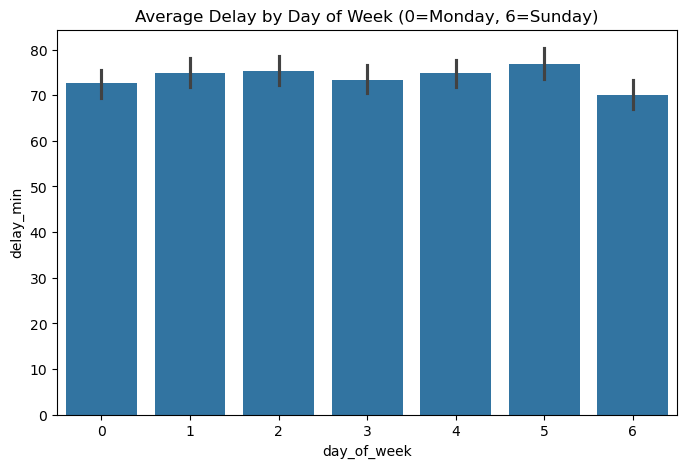

In [11]:
# 4. Day of Week vs Average Delay
plt.figure(figsize=(8,5))
sns.barplot(x="day_of_week", y="delay_min", data=df, estimator="mean")
plt.title("Average Delay by Day of Week (0=Monday, 6=Sunday)")
plt.show()

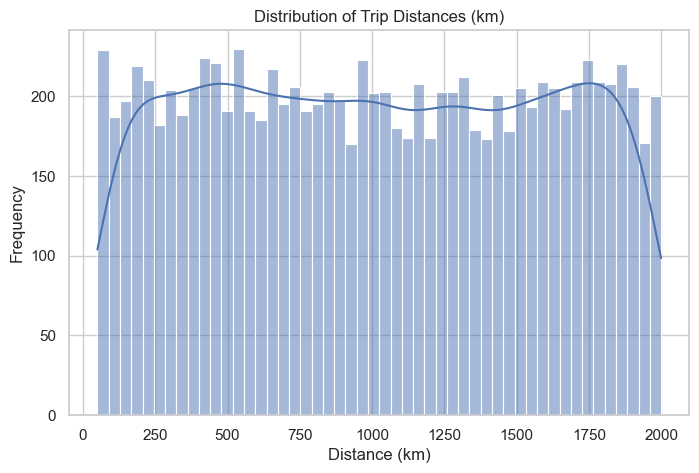

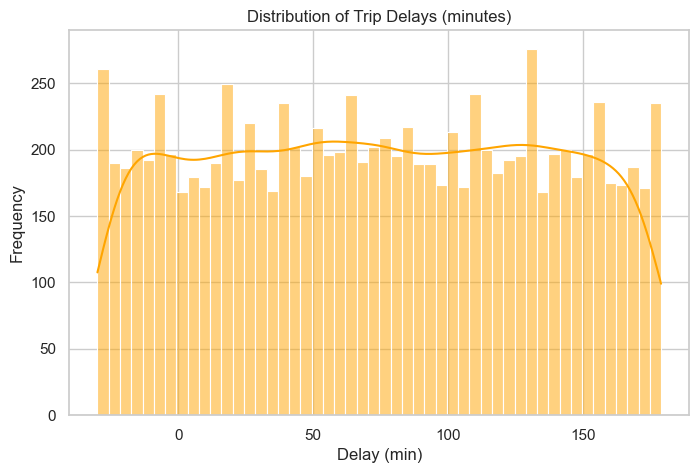

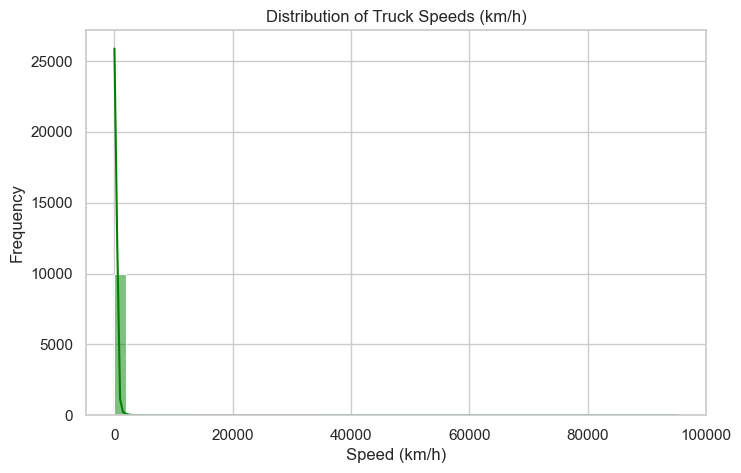

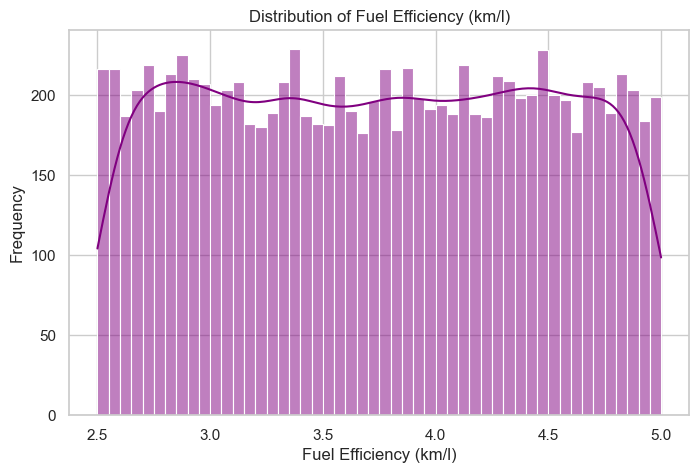

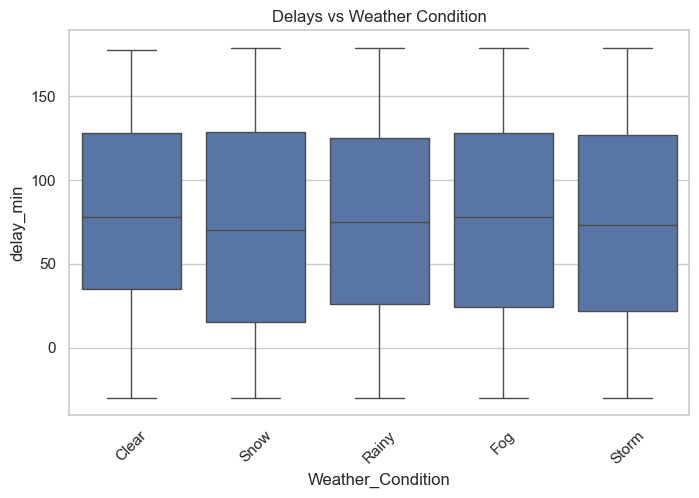

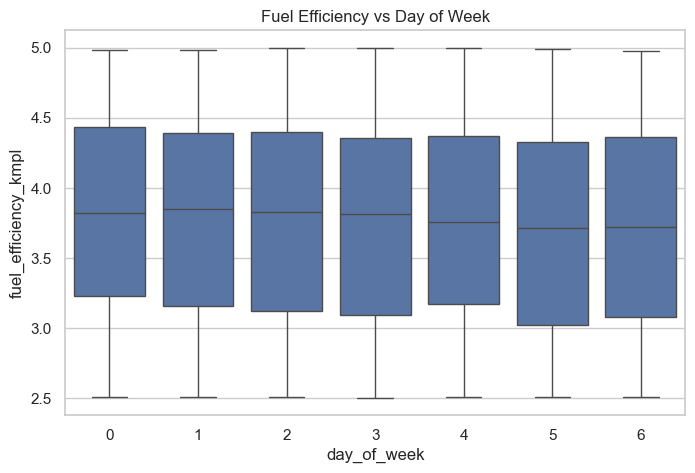

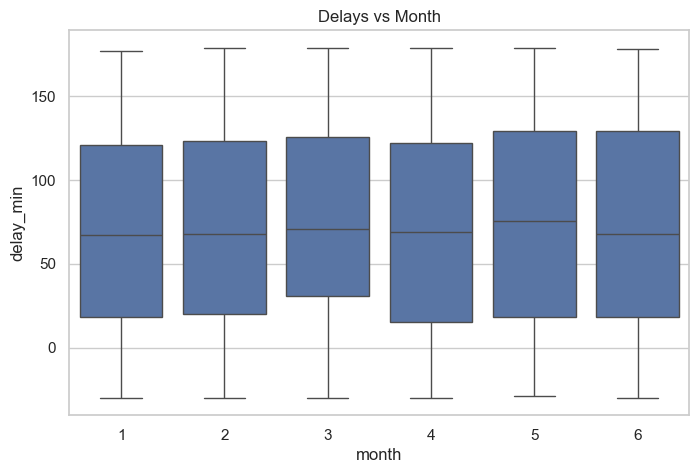

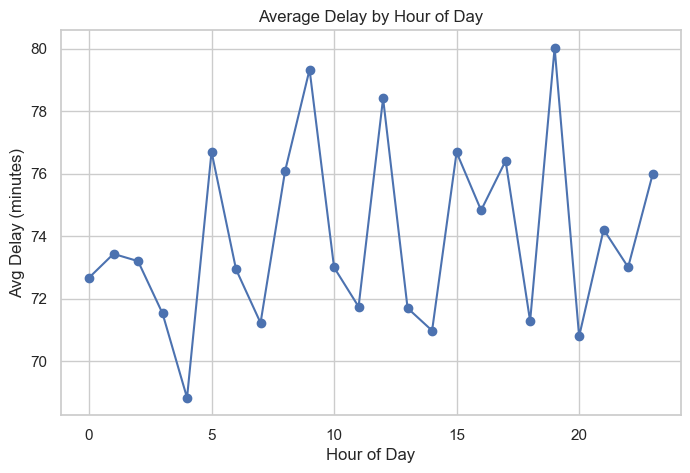

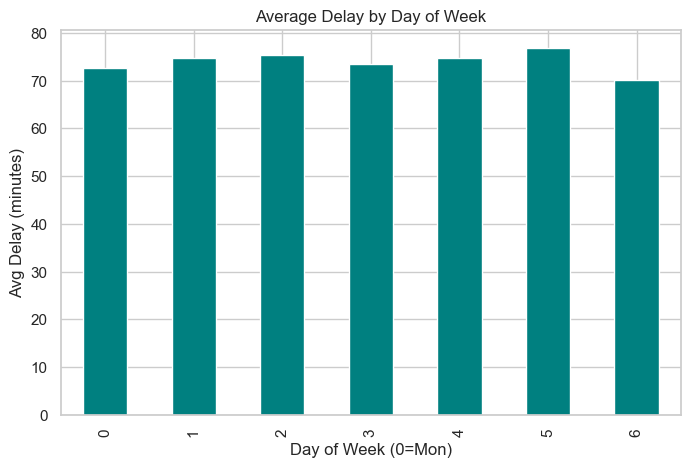

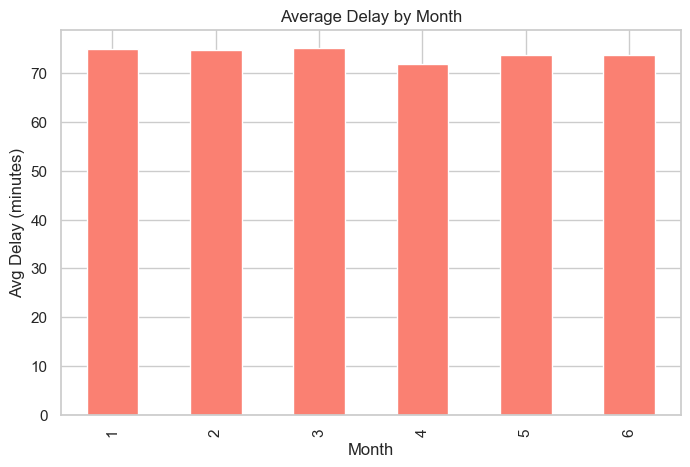

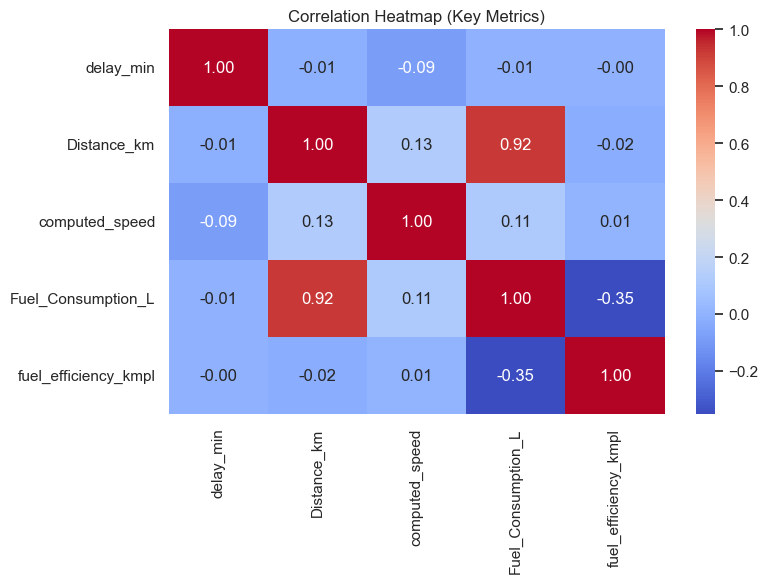

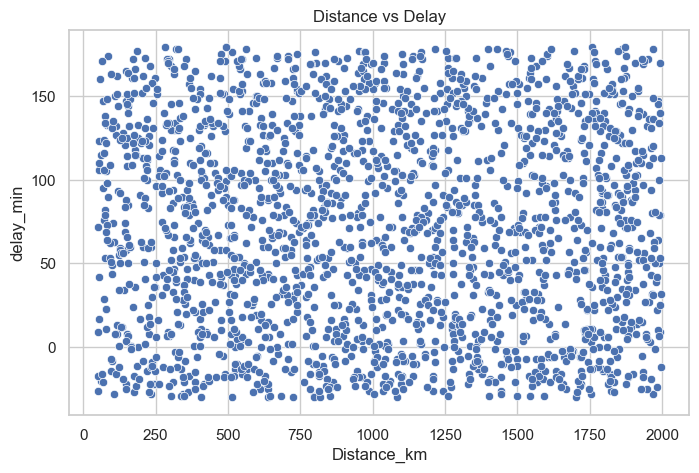

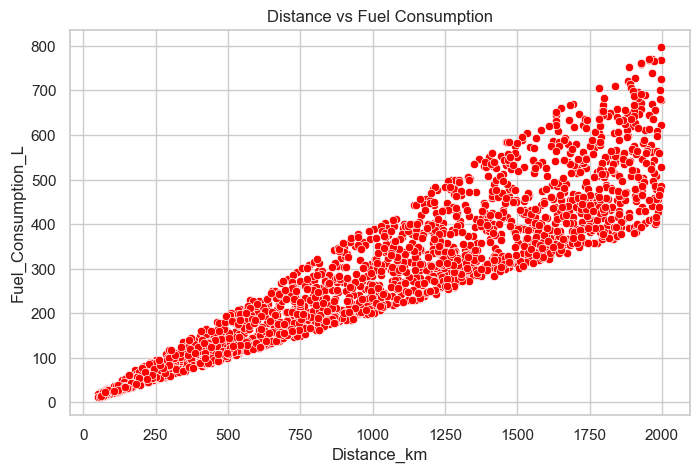

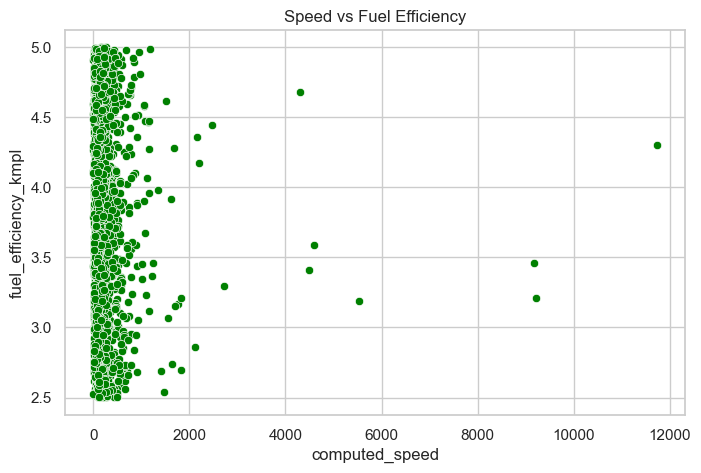

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)


# =======================================
# 1. DISTRIBUTIONS
# =======================================

# Distance Distribution
sns.histplot(df["Distance_km"], bins=50, kde=True)
plt.title("Distribution of Trip Distances (km)")
plt.xlabel("Distance (km)")
plt.ylabel("Frequency")
plt.show()
# 🎯 Objective: See how long trips generally are.
# 🔍 Finding: Likely most trips will cluster in short/mid ranges, outliers = long haul.

# Delay Distribution
sns.histplot(df["delay_min"], bins=50, kde=True, color="orange")
plt.title("Distribution of Trip Delays (minutes)")
plt.xlabel("Delay (min)")
plt.ylabel("Frequency")
plt.show()
# 🎯 Objective: Identify how much delay is common.
# 🔍 Finding: Expect positive delays (late trips) to dominate; negative (early trips) rare.

# Speed Distribution
sns.histplot(df["computed_speed"], bins=50, kde=True, color="green")
plt.title("Distribution of Truck Speeds (km/h)")
plt.xlabel("Speed (km/h)")
plt.ylabel("Frequency")
plt.show()
# 🎯 Objective: Check if average speeds are realistic.
# 🔍 Finding: Speeds should cluster ~40–80 km/h; extreme values = data errors.

# Fuel Efficiency Distribution
sns.histplot(df["fuel_efficiency_kmpl"], bins=50, kde=True, color="purple")
plt.title("Distribution of Fuel Efficiency (km/l)")
plt.xlabel("Fuel Efficiency (km/l)")
plt.ylabel("Frequency")
plt.show()
# 🎯 Objective: Evaluate fleet’s mileage performance.
# 🔍 Finding: Trucks typically 3–5 km/l; lower = inefficient driving, higher = efficient routes.


# =======================================
# 2. CATEGORY COMPARISONS
# =======================================

# Delay vs Weather
sns.boxplot(x="Weather_Condition", y="delay_min", data=df.sample(2000))
plt.title("Delays vs Weather Condition")
plt.xticks(rotation=45)
plt.show()
# 🎯 Objective: Understand weather’s impact on delays.
# 🔍 Finding: Rain/Snow/Fog should show higher delays than Clear/Cloudy.

# Fuel Efficiency vs Day of Week
sns.boxplot(x="day_of_week", y="fuel_efficiency_kmpl", data=df.sample(2000))
plt.title("Fuel Efficiency vs Day of Week")
plt.show()
# 🎯 Objective: See if weekdays vs weekends affect efficiency.
# 🔍 Finding: Weekdays may show lower efficiency due to traffic.

# Delay vs Month
sns.boxplot(x="month", y="delay_min", data=df.sample(2000))
plt.title("Delays vs Month")
plt.show()
# 🎯 Objective: Detect seasonal patterns in delays.
# 🔍 Finding: Monsoon months = more delays; summer/winter = fewer.


# =======================================
# 3. TIME TRENDS
# =======================================

# Avg Delay by Hour of Day
delay_by_hour = df.groupby("hour_of_day")["delay_min"].mean()
delay_by_hour.plot(kind="line", marker="o")
plt.title("Average Delay by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Avg Delay (minutes)")
plt.show()
# 🎯 Objective: Spot peak congestion times.
# 🔍 Finding: Morning/evening peaks likely show highest delays.

# Avg Delay by Day of Week
delay_by_day = df.groupby("day_of_week")["delay_min"].mean()
delay_by_day.plot(kind="bar", color="teal")
plt.title("Average Delay by Day of Week")
plt.xlabel("Day of Week (0=Mon)")
plt.ylabel("Avg Delay (minutes)")
plt.show()
# 🎯 Objective: Compare weekdays vs weekends.
# 🔍 Finding: Weekdays should show higher delays due to office traffic.

# Avg Delay by Month
delay_by_month = df.groupby("month")["delay_min"].mean()
delay_by_month.plot(kind="bar", color="salmon")
plt.title("Average Delay by Month")
plt.xlabel("Month")
plt.ylabel("Avg Delay (minutes)")
plt.show()
# 🎯 Objective: Long-term seasonal patterns.
# 🔍 Finding: Monsoon (Jul-Sep) delays may spike due to weather.
# 4. CORRELATION HEATMAP

corr_features = ["delay_min","Distance_km","computed_speed",
                 "Fuel_Consumption_L","fuel_efficiency_kmpl"]

sns.heatmap(df[corr_features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Key Metrics)")
plt.show()
# 🎯 Objective: See which metrics move together.
# 🔍 Finding: Distance ↔ Fuel consumption (strong +ve),
#             Speed ↔ Efficiency (possible inverted U relationship).



# 5. RELATIONSHIP SCATTERPLOTS


# Distance vs Delay
sns.scatterplot(x="Distance_km", y="delay_min", data=df.sample(2000))
plt.title("Distance vs Delay")
plt.show()
# 🎯 Objective: Check if long trips have more delays.
# 🔍 Finding: Longer trips may not always mean longer delays (depends on route/weather).

# Distance vs Fuel Consumption
sns.scatterplot(x="Distance_km", y="Fuel_Consumption_L", data=df.sample(2000), color="red")
plt.title("Distance vs Fuel Consumption")
plt.show()
# 🎯 Objective: Validate linear relationship.
# 🔍 Finding: More distance → higher fuel used, almost linear.

# Speed vs Fuel Efficiency
sns.scatterplot(x="computed_speed", y="fuel_efficiency_kmpl", data=df.sample(2000), color="green")
plt.title("Speed vs Fuel Efficiency")
plt.show()
# 🎯 Objective: Study how speed affects mileage.
# 🔍 Finding: Moderate speeds = best efficiency; too low/high = worse mileage.


✅ Summary: Phase 1 Visualization Objectives

Distributions → Understand spread of distance, delays, speed, efficiency.

Boxplots → Compare delays/fuel against categories (weather, weekday, month).

Time Trends → Spot patterns by hour/day/month.

Correlation Heatmap → Identify relationships between numeric factors.

Scatterplots → Validate key relationships visually (distance vs delay, etc).

-What Phase 1 Should Achieve

The purpose of Phase 1 is:

Clean & prepare data → handle missing, incorrect, or inconsistent values.

Engineer core metrics → delay, speed, fuel efficiency, traffic/weather factors.

Explore patterns → visualize distributions & correlations.

Extract insights → summarize what matters for route optimization.

- What We Already Did

Data Cleaning & Preparation

Converted datetime columns to datetime.

Created delay_min, computed_speed, fuel_efficiency_kmpl.

Verified values (checked for inf, negative delays, etc.).

Feature Engineering

Added hour_of_day, day_of_week, month.

Core KPIs now exist: delay, speed, fuel efficiency.

Visualization Plan & Code

Delay distribution (hist + KDE).

Average delay by day-of-week.

Fuel efficiency distribution.

Speed vs delay scatter.

Weather impact on delay.

Fuel efficiency by truck.

Monthly trend in average delay.

Correlation heatmap.

In [13]:
# Outlier detection for key metrics
print("🚨 Outlier Summary:")

# Speed outliers
speed_outliers = df[(df["computed_speed"] <= 0) | (df["computed_speed"] > 200)]
print(f"Speed outliers: {len(speed_outliers)} trips")

# Delay outliers (more than 3 std from mean)
delay_threshold = df["delay_min"].mean() + 3 * df["delay_min"].std()
delay_outliers = df[df["delay_min"] > delay_threshold]
print(f"Delay outliers: {len(delay_outliers)} trips")

# Fuel efficiency outliers
fuel_outliers = df[(df["fuel_efficiency_kmpl"] < 2) | (df["fuel_efficiency_kmpl"] > 6)]
print(f"Fuel efficiency outliers: {len(fuel_outliers)} trips")


🚨 Outlier Summary:
Speed outliers: 3775 trips
Delay outliers: 0 trips
Fuel efficiency outliers: 0 trips


In [14]:
import numpy as np

print("🚨 Outlier Detection using IQR:")

# Function to detect outliers with IQR
def detect_outliers(series, col_name):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    print(f"{col_name}: {len(outliers)} outliers (Lower={round(lower_bound,2)}, Upper={round(upper_bound,2)})")
    return outliers

# Apply to key metrics
delay_outliers = detect_outliers(df["delay_min"], "Delay (min)")
speed_outliers = detect_outliers(df["computed_speed"].replace([np.inf, -np.inf], np.nan).dropna(), "Speed (km/h)")
fuel_outliers = detect_outliers(df["fuel_efficiency_kmpl"], "Fuel Efficiency (km/L)")


🚨 Outlier Detection using IQR:
Delay (min): 0 outliers (Lower=-134.0, Upper=282.0)
Speed (km/h): 717 outliers (Lower=-185.27, Upper=530.17)
Fuel Efficiency (km/L): 0 outliers (Lower=1.19, Upper=6.29)


In [15]:
import numpy as np

print("🚨 Outlier Detection (Debug Mode)")

def detect_outliers(series, col_name):
    # Handle infinite values
    series = series.replace([np.inf, -np.inf], np.nan).dropna()
    
    # Basic stats
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Print range info
    print(f"\n{col_name} stats:")
    print(f"  Min={series.min()}, Max={series.max()}, Median={series.median()}")
    print(f"  IQR={IQR}, Lower Bound={lower_bound}, Upper Bound={upper_bound}")
    
    # Find outliers
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    print(f"  → Found {len(outliers)} outliers")
    
    # Show first few if they exist
    if len(outliers) > 0:
        print(outliers.head())
    
    return outliers

# Apply to key metrics
delay_outliers = detect_outliers(df["delay_min"], "Delay (min)")
speed_outliers = detect_outliers(df["computed_speed"], "Speed (km/h)")
fuel_outliers = detect_outliers(df["fuel_efficiency_kmpl"], "Fuel Efficiency (km/L)")


🚨 Outlier Detection (Debug Mode)

Delay (min) stats:
  Min=-30.0, Max=179.0, Median=74.0
  IQR=104.0, Lower Bound=-134.0, Upper Bound=282.0
  → Found 0 outliers

Speed (km/h) stats:
  Min=4.3881856540084385, Max=95280.0, Median=159.0084985835694
  IQR=178.8608628750666, Lower Bound=-185.27490086997696, Upper Bound=530.1685506302895
  → Found 717 outliers
22     711.724138
25     708.648649
52     806.222222
87     580.396040
182    780.000000
Name: computed_speed, dtype: float64

Fuel Efficiency (km/L) stats:
  Min=2.500313659419641, Max=5.0, Median=3.748802433259227
  IQR=1.2737703335821262, Lower Bound=1.1931355046796366, Upper Bound=6.288216839008141
  → Found 0 outliers


In [ ]:
# 🚨 Cleaning Speed Outliers
# Define realistic max speed for trucks (km/h)
MAX_TRUCK_SPEED = 150  

#  how many outliers exist before cleaning
outlier_count = (df["computed_speed"] > MAX_TRUCK_SPEED).sum()
print(f"⚠️ Found {outlier_count} unrealistic speed values (> {MAX_TRUCK_SPEED} km/h)")

# Replace outliers with NaN (to avoid distorting analysis)
df.loc[df["computed_speed"] > MAX_TRUCK_SPEED, "computed_speed"] = np.nan

# Optional – Fill NaN with median speed (so we don’t lose rows)
median_speed = df["computed_speed"].median()
df["computed_speed"] = df["computed_speed"].fillna(median_speed)


# ✅ Check after cleaning
print("\nSpeed column cleaned ✅")
print(df["computed_speed"].describe())


⚠️ Found 5279 unrealistic speed values (> 150 km/h)

Speed column cleaned ✅
count    10000.000000
mean        78.571388
std         28.245968
min          4.388186
25%         78.825793
50%         78.825793
75%         78.825793
max        150.000000
Name: computed_speed, dtype: float64


In [17]:
# Save the cleaned dataset for dashboard use
df.to_csv("clean_trips.csv", index=False)
print("✅ Clean dataset saved as clean_trips.csv")


✅ Clean dataset saved as clean_trips.csv


In [18]:
df.to_csv("C:\\Users\\DELL\\OneDrive\\Sana Projects\\EDA 1 smart route delay\\finaltruck_trip_data_10000_enriched.csv", index=False)
print("✅ Cleaned dataset saved as finaltruck_trip_data_10000_enriched.csv")


✅ Cleaned dataset saved as finaltruck_trip_data_10000_enriched.csv
